In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from src.rv_estimators import close_to_close_rv, parkinson_rv, garman_klass_rv, yang_zhang_rv, har_rv

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

def find_project_root(marker=".gitignore"):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"

sp = pd.read_parquet(DATA_DIR / "spy_prices.parquet")
vh = pd.read_parquet(DATA_DIR / "spy_volatility_history.parquet")
vix = pd.read_parquet(DATA_DIR / "vix_prices.parquet")
vix.index.name = 'date'

rv_21 = close_to_close_rv(sp["Close"], window=21)
park_rv_21 = parkinson_rv(sp['High'], sp['Low'], window=21)
klass_rv_21 = garman_klass_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)
yang_zhang_rv_21 = yang_zhang_rv(sp['High'], sp['Low'], sp['Open'], sp['Close'], window=21)

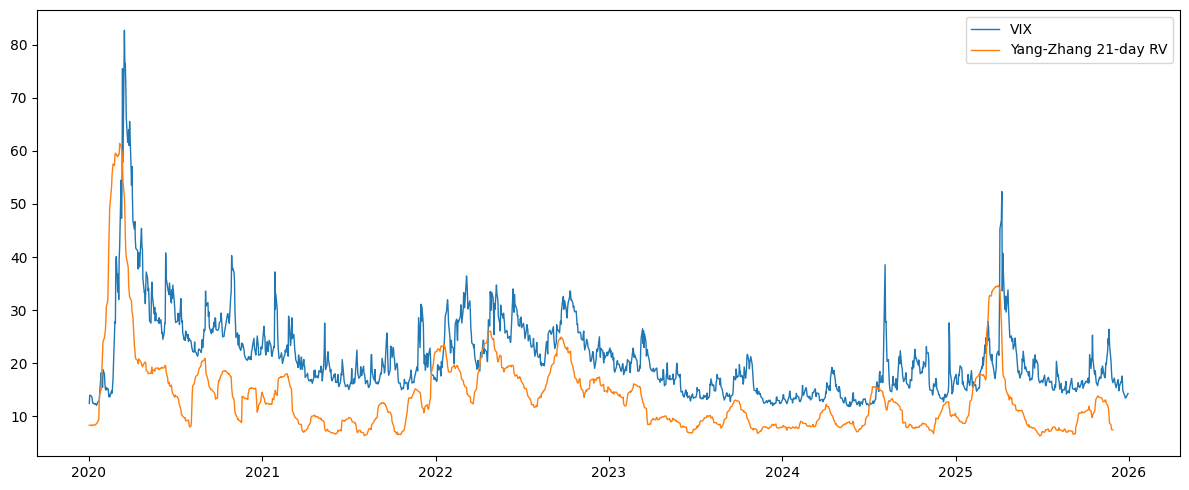

In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vix.index, vix['Close'], linewidth=1, label='VIX')
ax.plot(klass_rv_21.index, klass_rv_21.shift(-21) * 100, linewidth=1, label="Yang-Zhang 21-day RV")
plt.legend()
plt.tight_layout()
plt.show()

Mean VRP: 7.31
Median VRP: 7.41
Mean VRP excl. 2020: 7.04
Median VRP excl. 2020: 7.09
Mean VRP excl. shocks: 7.71
Median VRP excl. shocks: 7.45


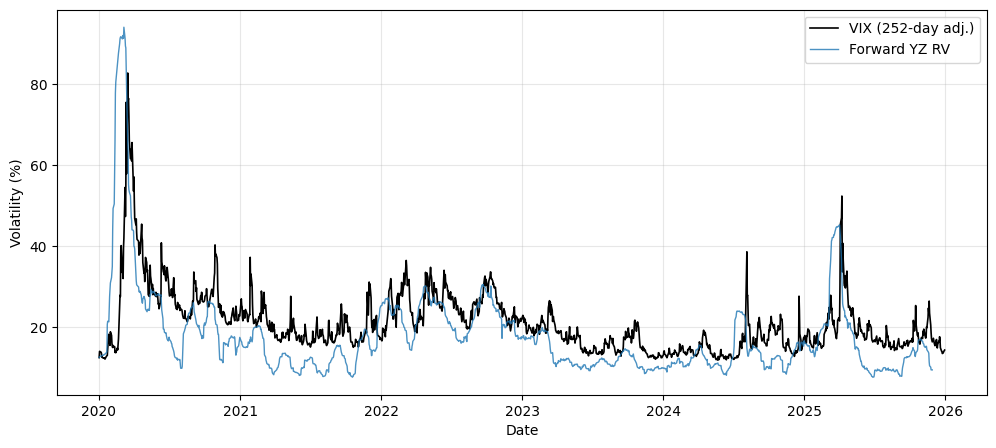

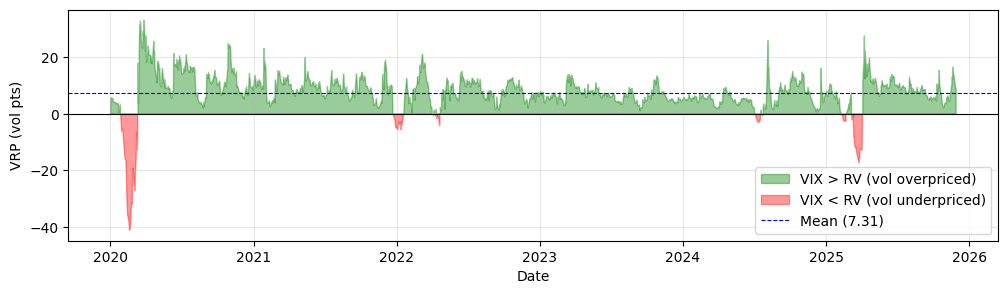

In [3]:
vix_adjusted = vix["Close"]

vrp = (vix_adjusted - klass_rv_21.shift(-21) * 100).dropna()

print(f"Mean VRP: {vrp.mean():.2f}")
print(f"Median VRP: {vrp.median():.2f}")
print(f"Mean VRP excl. 2020: {vrp.loc['2021':].mean():.2f}")
print(f"Median VRP excl. 2020: {vrp.loc['2021':].median():.2f}")
print(f"Mean VRP excl. shocks: {vrp[vrp > -20].mean():.2f}")
print(f"Median VRP excl. shocks: {vrp[vrp > -20].median():.2f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vix_adjusted.index, vix_adjusted, linewidth=1.2, label="VIX (252-day adj.)", color="black")
ax.plot(yang_zhang_rv_21.index, yang_zhang_rv_21.shift(-21) * 100, linewidth=1, alpha=0.8, label=f"Forward YZ RV")
ax.set_xlabel("Date")
ax.set_ylabel("Volatility (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show(fig)

fig2, ax2 = plt.subplots(figsize=(12, 3))
ax2.fill_between(vrp.index, vrp, 0, where=(vrp >= 0), alpha=0.4, color="green", label="VIX > RV (vol overpriced)")
ax2.fill_between(vrp.index, vrp, 0, where=(vrp < 0), alpha=0.4, color="red", label="VIX < RV (vol underpriced)")
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axhline(vrp.mean(), color="blue", linewidth=0.8, linestyle="--", label=f"Mean ({vrp.mean():.2f})")
ax2.set_xlabel("Date")
ax2.set_ylabel("VRP (vol pts)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower right")
plt.show(fig2)

In [4]:
overnight_returns = np.log(sp['Open'] / sp['Close'].shift(1))
intraday_returns = np.log(sp['Close'] / sp['Open'])

overnight_var = (overnight_returns ** 2).rolling(21).mean() * 252
intraday_var = (intraday_returns ** 2).rolling(21).mean() * 252
total_var = overnight_var + intraday_var

print(f"Mean overnight vol contribution: {np.sqrt(overnight_var.mean())*100:.1f}%")
print(f"Mean intraday vol contribution: {np.sqrt(intraday_var.mean())*100:.1f}%")
print(f"Overnight as % of total variance: {(overnight_var.mean() / total_var.mean())*100:.1f}%")

Mean overnight vol contribution: 13.9%
Mean intraday vol contribution: 15.3%
Overnight as % of total variance: 45.0%


                            OLS Regression Results                            
Dep. Variable:              RV Target   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     116.8
Date:                Fri, 01 May 2026   Prob (F-statistic):           3.83e-63
Time:                        17:13:43   Log-Likelihood:                 466.00
No. Observations:                 838   AIC:                            -924.0
Df Residuals:                     834   BIC:                            -905.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0413      0.008      5.103      0.0

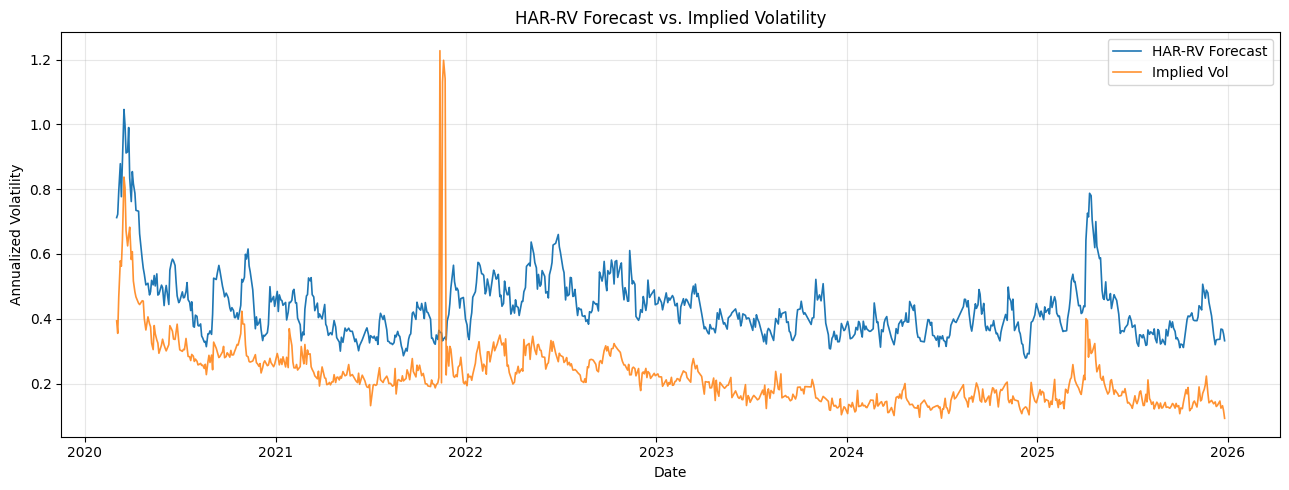

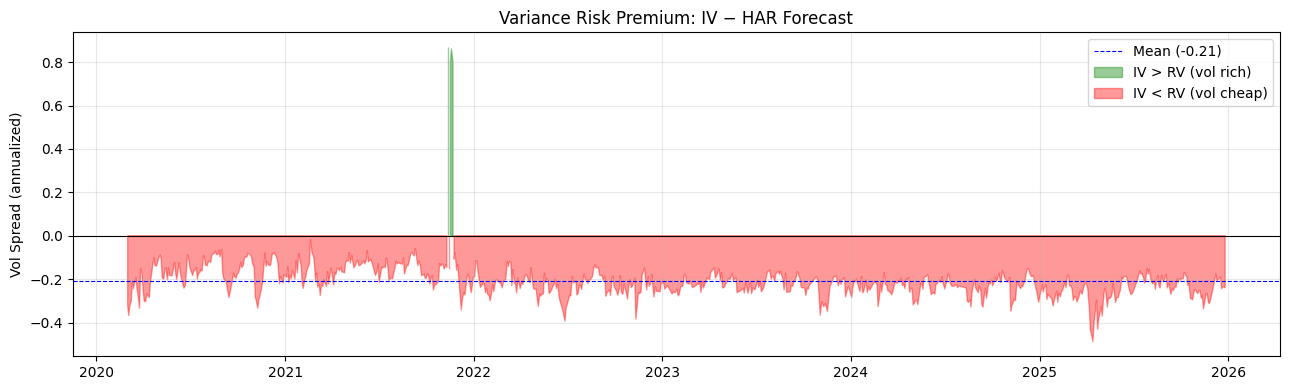

In [5]:
oc = pd.read_parquet(DATA_DIR / "spy_option_chain.parquet")
oc = oc[(oc['date'].dt.day_of_week < 5) & (oc['date'].dt.day_of_week != 1) & (oc['date'].dt.day_of_week != 3)]

oc = oc.set_index('date')

oc['dte'] = (pd.to_datetime(oc['expiration']) - pd.to_datetime(oc.index)).dt.days
oc = oc.drop_duplicates(subset=['strike', 'expiration', 'call_put'])

oc.index = pd.to_datetime(oc.index)
sp.index = pd.to_datetime(sp.index)

merged = oc.merge(sp, left_on='date', right_index = True, how='left')
merged = merged.dropna(subset=["Close"])

merged['moneyness'] = merged['strike'] / merged['Close']

atm_30d = merged[
    (merged['moneyness'].between(0.95, 1.05)) &
    (merged['dte'].between(20, 40))
]

iv_daily = atm_30d.groupby('date')['vol'].mean()

model, har = har_rv(merged)
print(model.summary())

har['HAR vol'] = np.sqrt(har['RV Forecast(t+1)'])

plot_df = pd.DataFrame({'HAR Forecast Vol': har['HAR vol'], 'Implied Vol': iv_daily}).dropna()

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df.index, plot_df['HAR Forecast Vol'], label='HAR-RV Forecast', linewidth=1.2)
ax.plot(plot_df.index, plot_df['Implied Vol'], label='Implied Vol', linewidth=1.2, alpha=0.85)
ax.set_title('HAR-RV Forecast vs. Implied Volatility')
ax.set_ylabel('Annualized Volatility')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_df['IV_minus_RV'] = plot_df['Implied Vol'] - plot_df['HAR Forecast Vol']

fig, ax = plt.subplots(figsize=(13, 4))
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(plot_df['IV_minus_RV'].mean(), color="blue", linewidth=0.8, linestyle="--", label=f"Mean ({plot_df['IV_minus_RV'].mean():.2f})")
ax.fill_between(plot_df.index, plot_df['IV_minus_RV'], 0,
                where=plot_df['IV_minus_RV'] > 0, alpha=0.4, color='green',  label='IV > RV (vol rich)')
ax.fill_between(plot_df.index, plot_df['IV_minus_RV'], 0,
                where=plot_df['IV_minus_RV'] < 0, alpha=0.4, color='red', label='IV < RV (vol cheap)')
ax.set_title('Variance Risk Premium: IV − HAR Forecast')
ax.set_ylabel('Vol Spread (annualized)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Find the spike
spike_date = plot_df['Implied Vol'].idxmax()
print("Spike date:", spike_date)
print("IV value:", plot_df.loc[spike_date, 'Implied Vol'])

# Look at the raw options data on that date
spike_data = oc[oc.index == spike_date]
print("\nNumber of contracts:", len(spike_data))
print("\nIV distribution on spike date:")
print(spike_data['vol'].describe())
print("\nFull spike day data:")
print(spike_data.head(20))

# Compare to a normal date nearby
normal_date = spike_date - pd.Timedelta(days=7)
normal_data = oc[oc.index == normal_date]
print(f"\nNormal date ({normal_date}) IV stats:")
print(normal_data['vol'].describe())

print(spike_data[['expiration', 'dte', 'strike', 'vol']].head(20))


Spike date: 2021-11-12 00:00:00
IV value: 1.22776

Number of contracts: 116

IV distribution on spike date:
count    116.000000
mean       1.088853
std        0.867273
min        0.024300
25%        0.407400
50%        0.797950
75%        1.593100
max        3.941200
Name: vol, dtype: float64

Full spike day data:
           act_symbol expiration  strike call_put     bid     ask     vol  \
date                                                                        
2021-11-12        SPY 2021-11-26   340.0     Call  127.63  127.74  3.9412   
2021-11-12        SPY 2021-11-26   340.0      Put    0.01    0.02  3.9412   
2021-11-12        SPY 2021-11-26   375.0     Call   92.67   92.78  3.1547   
2021-11-12        SPY 2021-11-26   375.0      Put    0.04    0.05  0.0243   
2021-11-12        SPY 2021-11-26   385.0     Call   82.68   82.79  2.9357   
2021-11-12        SPY 2021-11-26   385.0      Put    0.06    0.07  2.9357   
2021-11-12        SPY 2021-11-26   397.0     Call   70.72   70.82  2

                            OLS Regression Results                            
Dep. Variable:              RV Target   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     309.2
Date:                Fri, 01 May 2026   Prob (F-statistic):          8.30e-156
Time:                        17:16:04   Log-Likelihood:                 1327.1
No. Observations:                1484   AIC:                            -2646.
Df Residuals:                    1480   BIC:                            -2625.
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0219      0.005      4.115      0.0

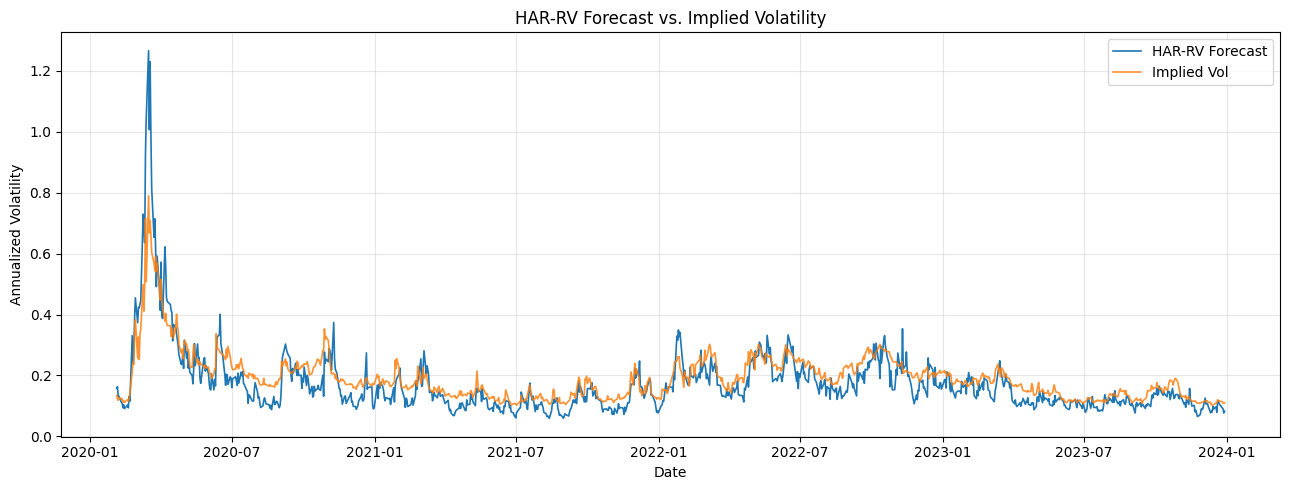

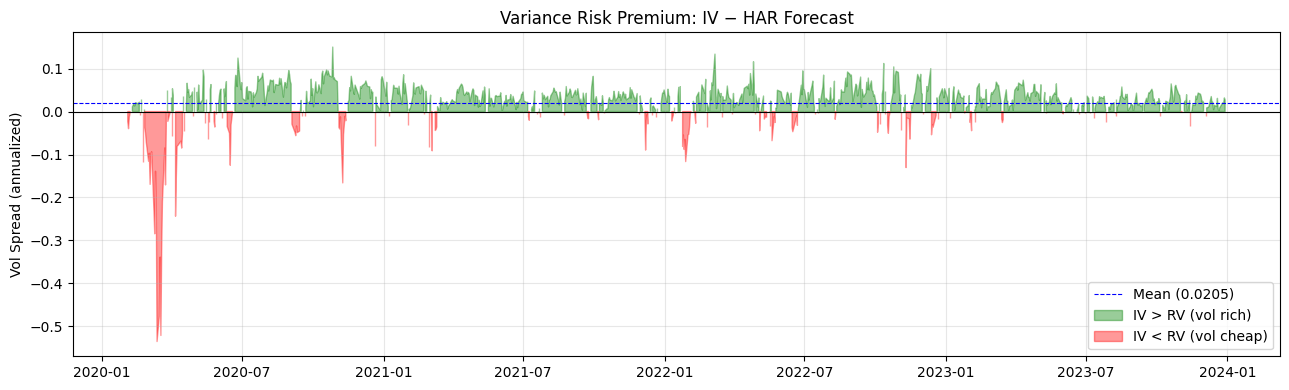

Mean HAR forecast: 0.1584
Mean OptionsDX IV: 0.1911
Mean VRP (DX - HAR): 0.0205


In [10]:
dx = pd.read_parquet(DATA_DIR / 'spy_options_optionsdx.parquet')
dx = dx.set_index('date')
dx.index = pd.to_datetime(dx.index)

atm_30d = dx[(dx['moneyness'].between(0.98, 1.02)) & (dx['dte'].between(20, 40))]

iv_daily = atm_30d.groupby('date')['vol'].mean()

model, har = har_rv(sp)
har['HAR vol'] = har['RV Forecast(t+1)']

plot_df = pd.DataFrame({
    'HAR Forecast Vol': har['HAR vol'],
    'Implied Vol': iv_daily,
}).dropna()
plot_df['IV_minus_RV'] = plot_df['Implied Vol'] - plot_df['HAR Forecast Vol']

print(model.summary())
print(plot_df['IV_minus_RV'].describe())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(plot_df.index, plot_df['HAR Forecast Vol'], label='HAR-RV Forecast', linewidth=1.2)
ax.plot(plot_df.index, plot_df['Implied Vol'], label='Implied Vol', linewidth=1.2, alpha=0.85)
ax.set_title('HAR-RV Forecast vs. Implied Volatility')
ax.set_ylabel('Annualized Volatility')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plot_df['IV_minus_RV'] = plot_df['Implied Vol'] - plot_df['HAR Forecast Vol']

fig, ax = plt.subplots(figsize=(13, 4))
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(plot_df['IV_minus_RV'].mean(), color="blue", linewidth=0.8, linestyle="--", label=f"Mean ({plot_df['IV_minus_RV'].mean():.4f})")
ax.fill_between(plot_df.index, plot_df['IV_minus_RV'], 0,
                where=plot_df['IV_minus_RV'] > 0, alpha=0.4, color='green',  label='IV > RV (vol rich)')
ax.fill_between(plot_df.index, plot_df['IV_minus_RV'], 0,
                where=plot_df['IV_minus_RV'] < 0, alpha=0.4, color='red', label='IV < RV (vol cheap)')
ax.set_title('Variance Risk Premium: IV − HAR Forecast')
ax.set_ylabel('Vol Spread (annualized)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean HAR forecast: {har['HAR vol'].mean():.4f}")
print(f"Mean OptionsDX IV: {iv_daily.mean():.4f}")
print(f"Mean VRP (DX - HAR): {(iv_daily - har['HAR vol']).reindex(iv_daily.index).dropna().mean():.4f}")

In [11]:
spread = (iv_daily - har['HAR vol']).dropna()
print(spread.describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]))
print(f"\n% days VRP > 0: {(spread > 0).mean()*100:.1f}%")
print(f"% days VRP > 0.02: {(spread > 0.02).mean()*100:.1f}%")
print(f"% days VRP > 0.05: {(spread > 0.05).mean()*100:.1f}%")

count    977.000000
mean       0.020480
std        0.053584
min       -0.535473
5%        -0.049585
10%       -0.021665
25%        0.008452
50%        0.027114
75%        0.045530
90%        0.063452
95%        0.075632
max        0.150187
dtype: float64

% days VRP > 0: 81.0%
% days VRP > 0.02: 60.9%
% days VRP > 0.05: 20.9%
